# MCP Policy Impact Analysis Workflow

This notebook integrates two AI agents:
1. **Rule Extraction Agent**: Extracts SBVR rules from new policy documents
2. **MCP GitHub Agent**: Fetches current rule configuration from GitHub and performs impact analysis

## Prerequisites:
1. GitHub Personal Access Token (for MCP GitHub integration)
2. OpenAI API Key
3. A GitHub repository with current policy rules configuration

In [1]:
import os
import json
from typing import TypedDict, List, Annotated, Dict, Any
import operator

from langgraph.graph import StateGraph, END, START
from langgraph.prebuilt import ToolNode
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage, AIMessage
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI

# LangChain MCP Adapter for GitHub integration
from langchain_mcp_adapters.client import MultiServerMCPClient

## 1. Define Enhanced State

Compared to the original agent, we need to track more information throughout the workflow:

In [2]:
class PolicyImpactAnalysisState(TypedDict):
    """Enhanced state for multi-workflow routing system"""
    # Conversation history
    messages: Annotated[List[BaseMessage], operator.add]
    
    # Current rules from GitHub repository (used in Impact Analysis workflow)
    current_rules: List[Dict[str, Any]]
    
    # Impact analysis report (used in Impact Analysis workflow)
    impact_report: str
    
    # Workflow routing flag - which workflow to execute
    workflow_type: str  # "rule_extraction" | "impact_analysis" | "qa" | "unknown"
    
    # User's original query
    user_query: str

## 2. Build the Toolbox

### Tool 1 & 2: Original SBVR Extraction and General QA Tools

In [3]:
# Import from the same directory (Agent 1)
from generic_engine_builder import build_search_engine

# Configure paths - adjusted for Agent 1 folder
INDEX_ROOT = os.path.join("..", "kyc_workflow", "output")
QA_PROMPT_PATH = "cust_local_search_system_prompt.txt"
SBVR_PROMPT_PATH = "sbvr_local_search_system_prompt.txt"
IMPACT_ANALYSIS_PROMPT_PATH = "impact_analysis_system_prompt.txt"

# Build SBVR extraction engine
print("🔧 Building SBVR Extraction engine...")
sbvr_engine = build_search_engine(
    index_root=INDEX_ROOT,
    system_prompt_path=SBVR_PROMPT_PATH,
    response_type="Return SBVR-style business rules in strict JSON format."
)

# Build general QA engine
print("🔧 Building General QA engine...")
qa_engine = build_search_engine(
    index_root=INDEX_ROOT,
    system_prompt_path=QA_PROMPT_PATH,
    response_type="multiple paragraphs"
)

print("🔧 Building Impact detect engine...")
impact_engine = build_search_engine(
    index_root=INDEX_ROOT,
    system_prompt_path=IMPACT_ANALYSIS_PROMPT_PATH,
    response_type="Return validation result in strict JSON format."
)
print("✅ Search engines ready!")

🔧 Building SBVR Extraction engine...
🔧 Building General QA engine...
🔧 Building Impact detect engine...
✅ Search engines ready!


In [4]:
@tool
async def sbvr_extraction(question: str) -> str:
    """
    Extract SBVR-formatted rules from policy documents.
    Use this when user asks to "extract rules", "find obligations", "list requirements", etc.
    
    Args:
        question: Question about rule extraction
    
    Returns:
        JSON string containing list of rules
    """
    print("🔍 Executing SBVR rule extraction...")
    try:
        result = await sbvr_engine.search(question)
        return result.response  # Return JSON string
    except Exception as e:
        return json.dumps({"error": str(e), "rules": []})

@tool
async def general_qa(question: str) -> str:
    """
    Answer general questions about policies.
    Suitable for definitions, summaries, background information, etc.
    """
    print("💬 Executing general Q&A...")
    try:
        result = await qa_engine.search(question)
        return result.response
    except Exception as e:
        return f"Error: {e}"

### Tool 3: GitHub MCP Integration (LangChain Adapter - HTTP Transport)

**Using LangChain MCP Adapter with HTTP Transport** to connect to GitHub's cloud MCP service.

In [5]:
# Initialize MCP Client for GitHub using LangChain Adapter
print("🔧 Initializing MCP GitHub Client with LangChain Adapter...")

async def initialize_mcp_github_client():
    """Initialize MCP client using LangChain adapter and return GitHub tools"""
    github_token = os.environ.get("GITHUB_PERSONAL_ACCESS_TOKEN", "")
    
    if not github_token:
        print("⚠️ Warning: GITHUB_PERSONAL_ACCESS_TOKEN not set")
        return None, []
    
    try:
        # Configure MCP client with GitHub server (HTTP Transport)
        print("🔌 Connecting to GitHub MCP Cloud Service (HTTP)...")
        client = MultiServerMCPClient({
            "github": {
                "transport": "http",
                "url": "https://api.githubcopilot.com/mcp/",
                "headers": {
                    "Authorization": f"Bearer {github_token}"
                }
            }
        })
        
        # Get all available GitHub tools (auto-discovery)
        tools = await client.get_tools()
        print(f"✅ MCP GitHub Client initialized with {len(tools)} tools available")
        
        # List available tools
        print("📋 Available GitHub tools:")
        for tool in tools:
            print(f"   - {tool.name}")
        
        return client, tools
    except Exception as e:
        print(f"❌ Failed to initialize MCP client: {e}")
        return None, []

# Initialize and get GitHub tools
mcp_client_result = await initialize_mcp_github_client()
print(mcp_client_result)
if mcp_client_result:
    mcp_github_client, github_mcp_tools = mcp_client_result
    # Find the get_file_contents tool
    github_read_file_tool = next(
        (t for t in github_mcp_tools if t.name == "get_file_contents"), 
        None
    )
    if github_read_file_tool:
        print(f"✅ Found GitHub file reading tool: {github_read_file_tool.name}")
    else:
        print("⚠️ get_file_contents tool not found in available tools")
else:
    mcp_github_client = None
    github_mcp_tools = []
    github_read_file_tool = None
    print("⚠️ GitHub MCP tools not available")

# Create a wrapper tool for our specific use case
@tool
async def fetch_current_policy_rules(owner: str, repo: str, file_path: str, branch: str = "main") -> Dict[str, Any]:
    """
    Fetch current policy rules configuration from GitHub repository using MCP Adapter.
    Returns a dictionary to update the graph's state.
    
    Args:
        owner: GitHub repository owner (username or organization)
        repo: Repository name
        file_path: Path to the rule configuration file (default: policy_rules.json)
        branch: Branch name (default: main)
    
    Returns:
        Dictionary with 'current_rules' key containing the rules list, or 'error' if failed
    
    Example:
        owner="myorg", repo="compliance-rules", file_path="config/policy_rules.json"
    """
    print(f"📥 Fetching current rules from GitHub: {owner}/{repo}/{file_path}")
    
    try:
        if not github_read_file_tool:
            raise Exception("GitHub MCP tools not initialized. Please check GITHUB_PERSONAL_ACCESS_TOKEN and MCP setup.")
        
        # Use the MCP tool to read file (LangChain tool interface)
        result = await github_read_file_tool.ainvoke({
            "owner": owner,
            "repo": repo,
            "path": file_path,
            "branch": branch
        })

        print(result)
        print(len(result))
        print(type(result))
        
        # Extract content from result
        content = None
        
        # Handle list of dictionaries (MCP format)
        if isinstance(result, list):
            # Find the text content (usually in the second element)
            for item in result:
                if isinstance(item, dict) and item.get('type') == 'text':
                    text = item.get('text', '')
                    # Skip metadata messages like "successfully downloaded..."
                    if not text.startswith('successfully downloaded'):
                        content = text
                        break
        else:
            content = str(result)
        
        if not content:
            raise Exception("Could not extract file content from MCP response")
        
        print(f"✅ Successfully fetched and extracted {len(content)} characters from GitHub")
        
        # Parse and return as state update dictionary
        rules_data = json.loads(content)
        current_rules = rules_data if isinstance(rules_data, list) else rules_data.get("rules", [])
        
        return {
            "current_rules": current_rules,
            "error": None
        }
                    
    except Exception as e:
        error_msg = f"Failed to fetch from GitHub: {str(e)}"
        print(f"❌ {error_msg}")
        
        # Return error in structured format
        return {
            "current_rules": [],
            "error": error_msg
        }

print("✅ GitHub MCP tool defined - Returns Dict for State Update")

🔧 Initializing MCP GitHub Client with LangChain Adapter...
🔌 Connecting to GitHub MCP Cloud Service (HTTP)...
✅ MCP GitHub Client initialized with 40 tools available
📋 Available GitHub tools:
   - add_comment_to_pending_review
   - add_issue_comment
   - assign_copilot_to_issue
   - create_branch
   - create_or_update_file
   - create_pull_request
   - create_repository
   - delete_file
   - fork_repository
   - get_commit
   - get_file_contents
   - get_label
   - get_latest_release
   - get_me
   - get_release_by_tag
   - get_tag
   - get_team_members
   - get_teams
   - issue_read
   - issue_write
   - list_branches
   - list_commits
   - list_issue_types
   - list_issues
   - list_pull_requests
   - list_releases
   - list_tags
   - merge_pull_request
   - pull_request_read
   - pull_request_review_write
   - push_files
   - request_copilot_review
   - search_code
   - search_issues
   - search_pull_requests
   - search_repositories
   - search_users
   - sub_issue_write
   - updat

### Tool 4: Impact Analysis (Core Functionality)

In [6]:
@tool
async def analyze_policy_impact(rules: List[Dict[str, Any]]) -> Dict[str, str]:
    """
    Analyze policy impact by validating each rule individually against latest documents.
    Uses the global impact_engine for per-rule validation.
    Takes rules directly from the state and returns a dictionary to update the state.
    
    Args:
        rules: List of rule dictionaries from the graph's state
    
    Returns:
        Dictionary with 'impact_report' key containing the analysis report
    """
    print("📊 Executing per-rule impact analysis...")
    
    try:
        current_rules = rules
        
        if not current_rules:
            return {"impact_report": "Error: No current rules provided or list is empty."}
        
        rule_count = len(current_rules)
        print(f"📥 Loaded {rule_count} current rules for analysis")
        
        # 2. Load the per-rule validation prompt template
        PER_RULE_PROMPT_PATH = "per_rule_validation_prompt.txt"
        with open(PER_RULE_PROMPT_PATH, "r", encoding="utf-8") as f:
            per_rule_prompt_template = f.read()
        
        # 3. Process each rule individually using global impact_engine
        validation_results = []
        
        for idx, rule in enumerate(current_rules, 1):
            rule_id = rule.get("id", f"UNKNOWN-{idx}")
            print(f"\n🔍 [{idx}/{rule_count}] Validating rule: {rule_id}")
            
            # Format the query for this specific rule
            rule_query = per_rule_prompt_template.format(
                rule_json=json.dumps(rule, ensure_ascii=False, indent=2)
            )
            
            # Execute validation query using global impact_engine
            try:
                result = await impact_engine.search(rule_query)
                validation_results.append({
                    "rule_id": rule_id,
                    "validation": result.response,
                    "success": True
                })
                print(f"✅ Rule {rule_id} validated")
            except Exception as e:
                print(f"❌ Error validating {rule_id}: {e}")
                validation_results.append({
                    "rule_id": rule_id,
                    "validation": f"Error: {str(e)}",
                    "success": False
                })
        
        # 4. Generate consolidated report
        print("\n📋 Generating consolidated impact analysis report...")
        
        report_sections = []
        for result in validation_results:
            if result["success"]:
                report_sections.append(f"## Rule: {result['rule_id']}\n\n{result['validation']}\n")
            else:
                report_sections.append(f"## Rule: {result['rule_id']}\n\n**Error**: {result['validation']}\n")
        
        final_report = "\n".join(report_sections)
        
        print(f"✅ Impact analysis complete for {rule_count} rules")
        
        # Return as state update dictionary
        return {"impact_report": final_report}
            
    except Exception as e:
        error_msg = f"Error: Impact analysis failed. Details: {str(e)}"
        print(f"❌ {error_msg}")
        return {"impact_report": error_msg}

print("✅ Enhanced per-rule analyze_policy_impact tool defined - Returns Dict for State Update")

✅ Enhanced per-rule analyze_policy_impact tool defined - Returns Dict for State Update


## 3. Multi-Workflow Routing System

### 3.1 Router Node 

In [7]:
# Initialize LLM for routing
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

def router_node(state: PolicyImpactAnalysisState) -> PolicyImpactAnalysisState:
    """
    Router node: Analyze user intent and decide which workflow to execute.
    
    This node uses LLM to classify the user's query into one of three workflows:
    1. rule_extraction: Extract SBVR rules from policy documents
    2. impact_analysis: Fetch current rules from GitHub and analyze impact
    3. qa: Answer general questions about policies
    """
    print("\n" + "="*60)
    print("🧭 ROUTER: Analyzing user intent...")
    print("="*60)
    
    messages = state["messages"]
    user_query = messages[-1].content if messages else ""
    
    # Create a classification prompt
    classification_prompt = f"""You are a workflow router. Analyze the user's query and classify it into ONE of these workflows:

1. **rule_extraction**: User wants to extract SBVR-formatted business rules from policy documents.
   - Keywords: "extract rules", "find obligations", "list requirements", "SBVR", "business rules"
   
2. **impact_analysis**: User wants to analyze the impact of policy changes by comparing current rules with latest documents.
   - Keywords: "impact analysis", "compare rules", "validate rules", "check changes", "policy impact"
   
3. **qa**: User has general questions about policies, definitions, or background information.
   - Keywords: "what is", "explain", "define", "tell me about", "summarize"

User Query: "{user_query}"

Respond with ONLY ONE WORD: rule_extraction, impact_analysis, or qa"""

    response = llm.invoke([HumanMessage(content=classification_prompt)])
    workflow_type = response.content.strip().lower()
    
    # Validate the response
    valid_workflows = ["rule_extraction", "impact_analysis", "qa"]
    if workflow_type not in valid_workflows:
        workflow_type = "qa"  # Default to QA if classification fails
    
    print(f"✅ Detected workflow: {workflow_type.upper()}")
    
    return {
        "workflow_type": workflow_type,
        "user_query": user_query
    }

print("✅ router_node defined")

✅ router_node defined


### 3.2 Workflow 1: SBVR Rule Extraction

In [8]:
async def rule_extraction_node(state: PolicyImpactAnalysisState) -> PolicyImpactAnalysisState:
    """
    Workflow 1: Extract SBVR rules from policy documents.
    This node calls the sbvr_extraction tool with the user's query.
    """
    print("\n" + "="*60)
    print("📋 WORKFLOW 1: SBVR Rule Extraction")
    print("="*60)
    
    user_query = state.get("user_query", "")
    
    # Call the SBVR extraction tool
    result = await sbvr_extraction.ainvoke({"question": user_query})
    
    # Format the response
    response_message = f"""✅ **SBVR Rule Extraction Complete**

{result}
"""
    
    print("✅ Rule extraction completed")
    
    return {
        "messages": [AIMessage(content=response_message)]
    }

print("✅ rule_extraction_node defined")

✅ rule_extraction_node defined


### 3.3 Workflow 2: Impact Analysis (Step 1 - Fetch Rules)

In [9]:
async def impact_analysis_fetch_node(state: PolicyImpactAnalysisState) -> PolicyImpactAnalysisState:
    """
    Workflow 2 - Step 1: Fetch current rules from GitHub.
    This node calls fetch_current_policy_rules with hardcoded parameters.
    """
    print("\n" + "="*60)
    print("📥 WORKFLOW 2 - STEP 1: Fetching Rules from GitHub")
    print("="*60)
    
    # Hardcoded GitHub parameters (can be made configurable later)
    owner = "JJchan123"
    repo = "compliance_rule_configuration"
    file_path = "policy_rules.json"
    branch = "main"
    
    # Call the fetch tool
    result = await fetch_current_policy_rules.ainvoke({
        "owner": owner,
        "repo": repo,
        "file_path": file_path,
        "branch": branch
    })
    
    # Handle the result
    if result.get("error"):
        error_msg = f"❌ Failed to fetch rules: {result['error']}"
        print(error_msg)
        return {
            "messages": [AIMessage(content=error_msg)],
            "current_rules": []
        }
    
    fetched_rules = result.get("current_rules", [])
    print(f"✅ Successfully fetched {len(fetched_rules)} rules from GitHub")
    
    # Update state with fetched rules
    return {
        "current_rules": fetched_rules
    }

print("✅ impact_analysis_fetch_node defined")

✅ impact_analysis_fetch_node defined


In [10]:
async def qa_node(state: PolicyImpactAnalysisState) -> PolicyImpactAnalysisState:
    """
    Workflow 3: Answer general questions about policies.
    This node calls the general_qa tool with the user's query.
    """
    print("\n" + "="*60)
    print("💬 WORKFLOW 3: General Q&A")
    print("="*60)
    
    user_query = state.get("user_query", "")
    
    # Call the QA tool
    result = await general_qa.ainvoke({"question": user_query})
    
    # Format the response
    response_message = f"""✅ **Answer**

{result}
"""
    
    print("✅ Q&A completed")
    
    return {
        "messages": [AIMessage(content=response_message)]
    }

print("✅ qa_node defined")

✅ qa_node defined


### 3.5 Workflow 3: General QA

In [11]:
async def impact_analysis_analyze_node(state: PolicyImpactAnalysisState) -> PolicyImpactAnalysisState:
    """
    Workflow 2 - Step 2: Analyze the impact of current rules.
    This node calls analyze_policy_impact with rules from the state.
    """
    print("\n" + "="*60)
    print("📊 WORKFLOW 2 - STEP 2: Analyzing Policy Impact")
    print("="*60)
    
    current_rules = state.get("current_rules", [])
    
    # Check if we have rules to analyze
    if not current_rules:
        error_msg = "⚠️ Cannot analyze impact: no rules were fetched in previous step."
        print(error_msg)
        return {
            "impact_report": "Error: No rules available for analysis.",
            "messages": [AIMessage(content=error_msg)]
        }
    
    # Call the analysis tool
    result = await analyze_policy_impact.ainvoke({"rules": current_rules})
    
    report = result.get("impact_report", "")
    
    # Format the final response
    final_message = f"""✅ **Impact Analysis Complete**

{report}

---
**Total Rules Analyzed**: {len(current_rules)}
"""
    
    print(f"✅ Impact analysis completed for {len(current_rules)} rules")
    
    # Update state with analysis report
    return {
        "impact_report": report,
        "messages": [AIMessage(content=final_message)]
    }

print("✅ impact_analysis_analyze_node defined")

✅ impact_analysis_analyze_node defined


### 3.4 Workflow 2: Impact Analysis (Step 2 - Analyze Impact)

## 4. Build Routed Workflow Graph

In [17]:
# Define routing function
def route_workflow(state: PolicyImpactAnalysisState) -> str:
    """
    Routing function: Decide which workflow to execute based on router's classification.
    """
    workflow_type = state.get("workflow_type", "qa")
    print(f"🔀 Routing to: {workflow_type}")
    return workflow_type

# Create state graph
workflow = StateGraph(PolicyImpactAnalysisState)

# Add all nodes
workflow.add_node("router", router_node)
workflow.add_node("rule_extraction", rule_extraction_node)
workflow.add_node("impact_analysis_fetch", impact_analysis_fetch_node)
workflow.add_node("impact_analysis_analyze", impact_analysis_analyze_node)
workflow.add_node("qa", qa_node)

# Define workflow structure
# START -> Router -> One of three workflows -> END
workflow.add_edge(START, "router")

# Conditional routing based on workflow_type
workflow.add_conditional_edges(
    "router",
    route_workflow,
    {
        "rule_extraction": "rule_extraction",
        "impact_analysis": "impact_analysis_fetch",
        "qa": "qa"
    }
)

# Rule extraction goes directly to END
workflow.add_edge("rule_extraction", END)

# Impact analysis has two sequential steps
workflow.add_edge("impact_analysis_fetch", "impact_analysis_analyze")
workflow.add_edge("impact_analysis_analyze", END)

# QA goes directly to END
workflow.add_edge("qa", END)

# Compile the graph
app = workflow.compile()

## 5. Visualize Multi-Workflow Graph

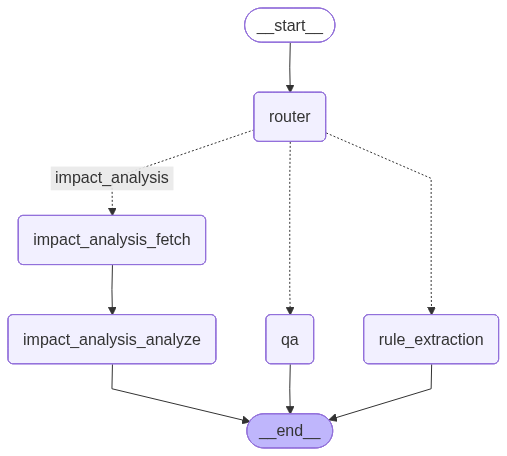

In [13]:
# Visualize graph structure if you have graphviz installed
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Cannot generate graph (graphviz required): {e}")

## 6. Run Multi-Workflow System

In [14]:
async def run_workflow(user_question: str):
    """
    Run the multi-workflow routing system with a user question.
    The router will automatically determine which workflow to execute.
    
    Args:
        user_question: User's question or request
    """
    print("🚀 Starting Multi-Workflow Routing System...")
    print("="*60)
    print(f"📝 User Question: {user_question}")
    print("="*60)
    
    # Create initial state
    initial_state = {
        "messages": [HumanMessage(content=user_question)],
        "current_rules": [],
        "impact_report": "",
        "workflow_type": "",
        "user_query": user_question
    }
    
    # Execute the workflow
    final_state = await app.ainvoke(initial_state)
    
    # Print final results
    print("\n" + "="*60)
    print("🎉 Workflow Execution Complete")
    print("="*60)
    
    # Display the final response
    final_message = final_state["messages"][-1]
    print("\n📋 Final Response:")
    print(final_message.content)
    
    return final_state

# Examples of how to use the system:
print("\n💡 Usage Examples:")
print("1. Rule Extraction:")
print('   result = await run_workflow("Extract all obligations related to non-account holder")')
print("\n2. Impact Analysis:")
print('   result = await run_workflow("Analyze the impact of current policy rules")')
print("\n3. General QA:")
print('   result = await run_workflow("What is KYC?")')

# Uncomment to run one of the workflows:
# result = await run_workflow("Analyze the impact of current policy rules")


💡 Usage Examples:
1. Rule Extraction:
   result = await run_workflow("Extract all obligations related to non-account holder")

2. Impact Analysis:
   result = await run_workflow("Analyze the impact of current policy rules")

3. General QA:
   result = await run_workflow("What is KYC?")


# Test Workflow

In [ ]:
result = await run_workflow("Do the impact analysis for the policy doument g33a ")
print("\n✅ Impact Analysis Workflow Tested")

🚀 Starting Multi-Workflow Routing System...
📝 User Question: Do the impact analysis for the policy doument g33a 

🧭 ROUTER: Analyzing user intent...
✅ Detected workflow: IMPACT_ANALYSIS
🔀 Routing to: impact_analysis

📥 WORKFLOW 2 - STEP 1: Fetching Rules from GitHub
📥 Fetching current rules from GitHub: JJchan123/compliance_rule_configuration/policy_rules.json
[{'type': 'text', 'text': 'successfully downloaded text file (SHA: fa4470fbcdf8486cf8b4c09447d599cd52885ac9)', 'id': 'lc_dce847fb-5f00-4152-81e9-30adfb75eb8c'}, {'type': 'text', 'text': '[\n  {\n    "id": "CUST-ACCEPT-001",\n    "source_reference": "g33a: SUPPLEMENT TO THE GUIDELINE ON PREVENTION OF MONEY LAUNDERING, Section 2. Customer Acceptance Policy",\n    "clause_reference": "2.2",\n    "data_support": null,\n    "subject": "authorized institution",\n    "modality": "obligation",\n    "condition": "when designing customer onboarding and customer acceptance policies and the customer acceptance policy is not defined",\n    "a

Reached token limit - reverting to previous context state


✅ Rule CUST-ACCEPT-001 validated

🔍 [2/31] Validating rule: CUST-ACCEPT-002


Reached token limit - reverting to previous context state


✅ Rule CUST-ACCEPT-002 validated

🔍 [3/31] Validating rule: CUST-ACCEPT-003


...

✅ Rule GOV-002 validated

🔍 [30/31] Validating rule: GOV-003


Reached token limit - reverting to previous context state


✅ Rule GOV-003 validated

🔍 [31/31] Validating rule: GOV-004


Reached token limit - reverting to previous context state


✅ Rule GOV-004 validated

📋 Generating consolidated impact analysis report...
✅ Impact analysis complete for 31 rules
✅ Impact analysis completed for 31 rules

🎉 Workflow Execution Complete

📋 Final Response:
✅ **Impact Analysis Complete**

## Rule: CUST-ACCEPT-001

{
  "original_rule_id": "CUST-ACCEPT-001",
  "status": "UNCHANGED",
  "latest_source_reference": "g33a: SUPPLEMENT TO THE GUIDELINE ON PREVENTION OF MONEY LAUNDERING, Section 2. Customer acceptance policy",
  "latest_clause_reference": "2.2",
  "change_analysis": "The condition remains focused on the requirement for an AI to develop customer acceptance policies when not defined. The core obligation to define and implement policies to identify higher-than-average money laundering risk customers is consistent. The action steps are fully aligned: developing policies and procedures to identify higher risk customer types, adopting more extensive due diligence for higher-risk customers, and establishing clear internal guidelines 

In [20]:
result = await run_workflow("Extract all obligations related to non-account holder")
print("\n✅ Impact Analysis Workflow Tested")

🚀 Starting Multi-Workflow Routing System...
📝 User Question: Extract all obligations related to non-account holder

🧭 ROUTER: Analyzing user intent...
✅ Detected workflow: RULE_EXTRACTION
🔀 Routing to: rule_extraction

📋 WORKFLOW 1: SBVR Rule Extraction
🔍 Executing SBVR rule extraction...


✅ Rule extraction completed

🎉 Workflow Execution Complete

📋 Final Response:
✅ **SBVR Rule Extraction Complete**

{
  "rules": [
    {
      "id": "NAH-R-001",
      "source_reference": "g33a: SUPPLEMENT TO THE GUIDELINE ON PREVENTION OF MONEY LAUNDERING, Section 3. Customer due diligence, Author: None",
      "clause_reference": "3.10, 3.11",
      "data_support": "[Data: Entities (282, 84); Relationships (128, 441); TextUnits (26, 25)]",
      "subject": "authorized institution",
      "modality": "obligation",
      "condition": "when carrying out transactions exceeding HK$120,000 on behalf of a non-account holder regardless of whether the transaction is single or multiple operations with obvious connection",
      "action": "identify and verify the direct customer and any natural persons representing the customer, verify beneficial owners, understand ownership structure if corporate, and ascertain intended nature and purpose of the transaction",
      "action_steps": [
        "id